In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xml.etree.ElementTree as ET

In [2]:
# =============================================================================
# 1. CARGA Y CONSOLIDACIÓN DE DATOS
# =============================================================================
# Datos extraídos de la Tabla 14 de la tesis de E. Sarango (2025)
# Representan los aforos vehiculares realizados mediante detección con YOLOv5
# en la intersección de estudio.
data = {
    'Muestra_Video': ['ANALISIS_1', 'ANALISIS_2', 'ANALISIS_3', 'ANALISIS_4', 'ANALISIS_5', 'ANALISIS_6', 'ANALISIS_7'],
    'Vehiculos_Detectados': [135, 60, 33, 116, 120, 132, 38],
    'Tiempo_segundos': [410, 192, 92, 330, 344, 410, 119]
}

df = pd.DataFrame(data)

# Cálculo de métricas de flujo para estandarizar los tiempos de las muestras
# (vehículos por segundo, minuto y hora)
df['Flujo_veh_seg'] = df['Vehiculos_Detectados'] / df['Tiempo_segundos']
df['Flujo_veh_min'] = df['Flujo_veh_seg'] * 60
df['Flujo_veh_hora'] = df['Flujo_veh_seg'] * 3600

In [3]:
# =============================================================================
# 2. ANÁLISIS ESTADÍSTICO DESCRIPTIVO
# =============================================================================
# Calculamos las métricas clave (media, desviación estándar, mínimos y máximos) 
# para comprender el comportamiento de la intersección a partir de la muestra.
resumen_estadistico = df[['Vehiculos_Detectados', 'Flujo_veh_min', 'Flujo_veh_hora']].describe()

flujo_promedio_hora = df['Flujo_veh_hora'].mean()
flujo_maximo_hora = df['Flujo_veh_hora'].max()
flujo_minimo_hora = df['Flujo_veh_hora'].min()

print("--- RESUMEN ESTADÍSTICO DEL FLUJO VEHICULAR ---")
print(resumen_estadistico.round(2))
print("\n")

--- RESUMEN ESTADÍSTICO DEL FLUJO VEHICULAR ---
       Vehiculos_Detectados  Flujo_veh_min  Flujo_veh_hora
count                  7.00           7.00            7.00
mean                  90.57          20.08         1204.51
std                   45.12           1.09           65.39
min                   33.00          18.75         1125.00
25%                   49.00          19.24         1154.30
50%                  116.00          19.76         1185.37
75%                  126.00          21.01         1260.63
max                  135.00          21.52         1291.30




C:\Users\Santiago\AppData\Local\Temp\ipykernel_19340\1104027813.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Muestra_Video', y='Vehiculos_Detectados', ax=ax[0], palette="viridis")


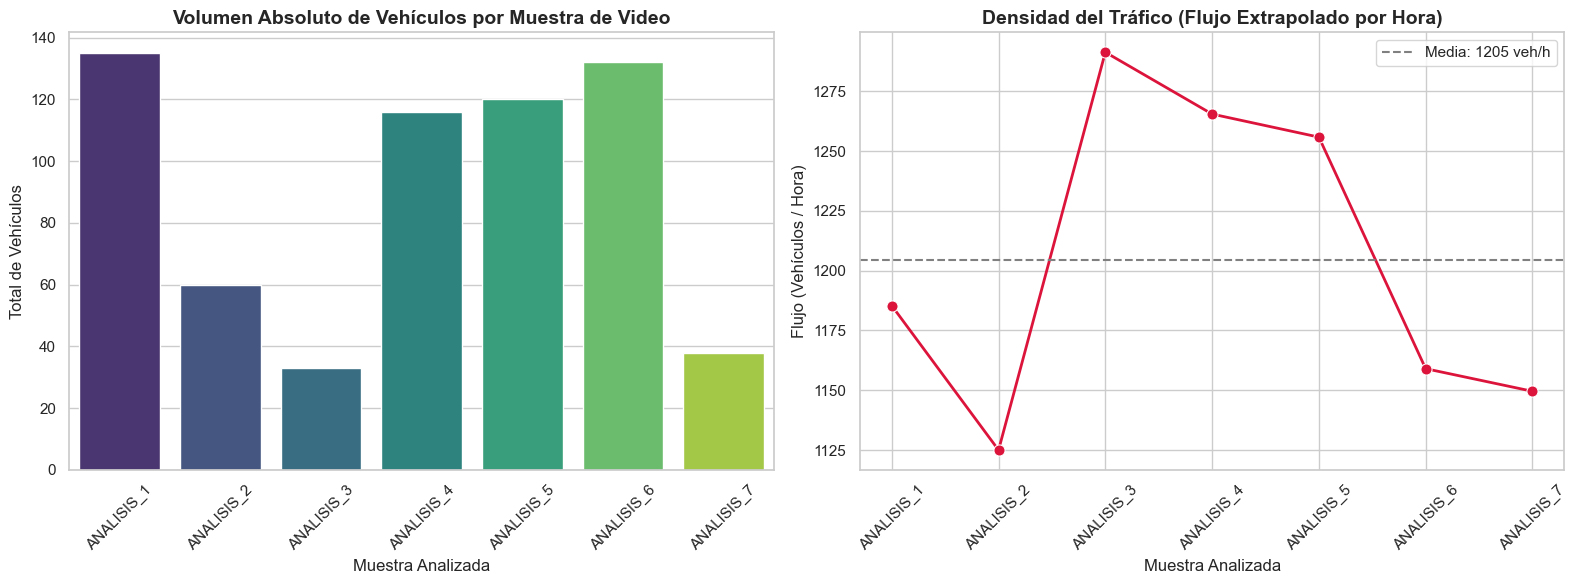

In [4]:
# =============================================================================
# 3. VISUALIZACIONES DEL COMPORTAMIENTO REAL
# =============================================================================
# Configuramos el estilo visual de seaborn para gráficas académicas
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Cantidad absoluta de vehículos detectados por muestra
sns.barplot(data=df, x='Muestra_Video', y='Vehiculos_Detectados', ax=ax[0], palette="viridis")
ax[0].set_title('Volumen Absoluto de Vehículos por Muestra de Video', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Muestra Analizada', fontsize=12)
ax[0].set_ylabel('Total de Vehículos', fontsize=12)
ax[0].tick_params(axis='x', rotation=45)

# Gráfico 2: Variación de la densidad del tráfico (Flujo extrapolado por hora)
sns.lineplot(data=df, x='Muestra_Video', y='Flujo_veh_hora', ax=ax[1], marker='o', color='crimson', linewidth=2, markersize=8)
# Añadimos la línea de la media para tener una referencia visual
ax[1].axhline(y=flujo_promedio_hora, color='gray', linestyle='--', label=f'Media: {flujo_promedio_hora:.0f} veh/h')

ax[1].set_title('Densidad del Tráfico (Flujo Extrapolado por Hora)', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Muestra Analizada', fontsize=12)
ax[1].set_ylabel('Flujo (Vehículos / Hora)', fontsize=12)
ax[1].tick_params(axis='x', rotation=45)
ax[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

In [5]:
# =============================================================================
# 4. CONCLUSIONES DEL ANÁLISIS
# =============================================================================
print("\n--- CONCLUSIONES EMPÍRICAS DEL EDA ---")
print(f"El análisis exploratorio de las {len(df)} muestras de video demuestra que la intersección ")
print(f"evaluada presenta una alta variabilidad en su carga vehicular a lo largo del tiempo.")
print(f"En las condiciones observadas, la intersección maneja un flujo promedio validado de {flujo_promedio_hora:.0f} veh/h.")
print(f"Además, se identifican periodos de mayor concentración con picos que alcanzan hasta los {flujo_maximo_hora:.0f} veh/h, ")
print(f"contrastando fuertemente con momentos de menor carga ({flujo_minimo_hora:.0f} veh/h). ")


--- CONCLUSIONES EMPÍRICAS DEL EDA ---
El análisis exploratorio de las 7 muestras de video demuestra que la intersección 
evaluada presenta una alta variabilidad en su carga vehicular a lo largo del tiempo.
En las condiciones observadas, la intersección maneja un flujo promedio validado de 1205 veh/h.
Además, se identifican periodos de mayor concentración con picos que alcanzan hasta los 1291 veh/h, 
contrastando fuertemente con momentos de menor carga (1125 veh/h). 
